# Greedy heuristics for the TSP: nearest neighbour and greedy edge

The Traveling Salesman Problem (TSP) asks for the shortest Hamiltonian cycle through $n$ cities. With $x_{ij}\in\{0,1\}$ equal to 1 when the tour goes from city $i$ to city $j$, and distances $d_{ij}$ (Reinelt, 1991; Jünger et al., 1995):

$$
\min_{x}\; \sum_{i=1}^{n}\sum_{j\ne i} d_{ij}x_{ij}
\quad\text{s.t.}\quad \sum_{j\ne i}x_{ij}=1,\qquad \sum_{i\ne j}x_{ij}=1,\qquad \sum_{i\in S}\sum_{j\in S}x_{ij}\le |S|-1\;\;\;\forall S\subset V,\; 2\le |S|\le n-1 .
$$

The problem is NP-hard, so large instances are attacked with heuristics. This notebook implements two **constructive heuristics** (with no local-improvement phase), **nearest neighbour** and **greedy edge** (*multi-fragment*), runs them on the 111 TSPLIB instances in the folder `ALL_tsp/` and measures their quality against the known optimal tours.

1. Load the instances
2. Candidate neighbours
3. The heuristics
4. Run on all the instances
5. Results: gaps, computational times and plots

In [1]:
import os
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree

DATA_DIR = Path("ALL_tsp")  # folder with the unzipped .tsp and .opt.tour files
K_NEIGHBORS = 10            # candidate neighbours per node
EXACT_MAX = 2500            # up to this size greedy edge uses ALL the edges
PI_TSPLIB = 3.141592        # TSPLIB fixes this value of PI in the GEO distances
print(f"{len(list(DATA_DIR.glob('*.tsp')))} .tsp instances in '{DATA_DIR}/'")
if not any(DATA_DIR.glob("*.tsp")):
    raise FileNotFoundError(
        f"No .tsp files in '{DATA_DIR.resolve()}'. Put the unzipped ALL_tsp folder (with the .tsp files "
        "directly inside) next to the notebook, or adjust DATA_DIR."
    )

111 .tsp instances in 'ALL_tsp/'


## 1. Load the instances

A TSPLIB file has a header (`DIMENSION`, `EDGE_WEIGHT_TYPE`, ...) and one or more sections. Distances are given in two ways:

* **Coordinates** (`NODE_COORD_SECTION`), with the distance defined by `EDGE_WEIGHT_TYPE`: `EUC_2D` (Euclidean, rounded to the nearest integer), `CEIL_2D` (Euclidean, rounded up), `ATT` (pseudo-Euclidean) and `GEO` (geographical distance on the sphere, with coordinates in degrees.minutes format).
* **Explicit matrix** (`EXPLICIT`), in full or triangular format.

Distances are always **integers** computed with the exact TSPLIB formulas: other formulas (or a different value of $\pi$) do not reproduce the published optima. The instance `linhp318` also has a fixed edge (`FIXED_EDGES_SECTION`) that the tour must contain.

`name.opt.tour` holds a known optimal tour (nodes numbered from 1 and ended by `-1`) for 32 of the instances.

In [2]:
class Instance:
    """Symmetric TSP instance. Stores either coordinates or an explicit matrix."""

    def __init__(self, name, ewt, coords=None, matrix=None, fixed=()):
        self.name = name
        self.ewt = ewt
        self.coords = coords
        self.matrix = matrix
        self.fixed = list(fixed)  # edges (u, v) that the tour must contain
        self.n = len(coords) if coords is not None else len(matrix)
        if ewt == "GEO":
            # DDD.MM coordinates -> radians (the integer part is truncated, as in Concorde)
            def to_rad(v):
                deg = np.trunc(v)
                minutes = v - deg
                return PI_TSPLIB * (deg + 5.0 * minutes / 3.0) / 180.0
            self.lat = to_rad(coords[:, 0])
            self.lon = to_rad(coords[:, 1])

    # -- vectorised distances: i, j are scalars or arrays (with broadcasting) ---
    def dist(self, i, j):
        if self.matrix is not None:
            return self.matrix[i, j]
        if self.ewt == "GEO":
            lat_i, lon_i = self.lat[i], self.lon[i]
            lat_j, lon_j = self.lat[j], self.lon[j]
            q1 = np.cos(lon_i - lon_j)
            q2 = np.cos(lat_i - lat_j)
            q3 = np.cos(lat_i + lat_j)
            v = np.clip(0.5 * ((1.0 + q1) * q2 - (1.0 - q1) * q3), -1.0, 1.0)
            return np.floor(6378.388 * np.arccos(v) + 1.0)
        dx = self.coords[i, 0] - self.coords[j, 0]
        dy = self.coords[i, 1] - self.coords[j, 1]
        if self.ewt == "EUC_2D":
            return np.floor(np.sqrt(dx * dx + dy * dy) + 0.5)
        if self.ewt == "CEIL_2D":
            return np.ceil(np.sqrt(dx * dx + dy * dy))
        if self.ewt == "ATT":
            r = np.sqrt((dx * dx + dy * dy) / 10.0)
            t = np.floor(r + 0.5)
            return np.where(t < r, t + 1.0, t)
        raise ValueError(f"Unsupported EDGE_WEIGHT_TYPE: {self.ewt}")

    def tour_length(self, tour):
        tour = np.asarray(tour)
        return float(self.dist(tour, np.roll(tour, -1)).sum())

    # -- space in which the k-d tree ranks neighbours correctly -------------------
    def kd_points(self):
        if self.ewt == "GEO":  # unit sphere: chord length ranks points like geodesic distance
            return np.column_stack([
                np.cos(self.lat) * np.cos(self.lon),
                np.cos(self.lat) * np.sin(self.lon),
                np.sin(self.lat)])
        return self.coords

In [3]:
def _read_sections(path):
    """Return (header, {section_name: [lines]}). Each *_SECTION keeps its own body."""
    header, sections, current = {}, {}, None
    with open(path, errors="ignore") as fh:
        for raw in fh:
            line = raw.strip()
            if not line:
                continue
            if line == "EOF":
                break
            if line.rstrip(":").endswith("_SECTION"):
                current = line.rstrip(":")
                sections[current] = []
            elif current is not None:
                sections[current].append(line)
            elif ":" in line:
                k, v = line.split(":", 1)
                header[k.strip().upper()] = v.strip()
    return header, sections


def _numbers(lines):
    return [t for line in lines for t in line.split()]


def read_tsp(path):
    header, sec = _read_sections(path)
    n = int(header["DIMENSION"])
    ewt = header["EDGE_WEIGHT_TYPE"].upper()
    name = header.get("NAME", os.path.basename(path))
    fixed = []
    if "FIXED_EDGES_SECTION" in sec:
        vals = [int(t) for t in _numbers(sec["FIXED_EDGES_SECTION"]) if t != "-1"]
        fixed = [(vals[i] - 1, vals[i + 1] - 1) for i in range(0, len(vals) - 1, 2)]
    if ewt == "EXPLICIT":
        fmt = header["EDGE_WEIGHT_FORMAT"].upper()
        vals = np.array([float(t) for t in _numbers(sec["EDGE_WEIGHT_SECTION"])])
        m = np.zeros((n, n))
        if fmt == "FULL_MATRIX":
            m = vals.reshape(n, n)
        else:
            idx = {"UPPER_ROW": np.triu_indices(n, 1), "LOWER_ROW": np.tril_indices(n, -1),
                   "UPPER_DIAG_ROW": np.triu_indices(n, 0),
                   "LOWER_DIAG_ROW": np.tril_indices(n, 0)}[fmt]
            m[idx] = vals
            m = np.maximum(m, m.T)  # symmetrise (the filled triangle dominates)
        np.fill_diagonal(m, 0.0)
        return Instance(name, ewt, matrix=m, fixed=fixed)
    rows = [line.split() for line in sec["NODE_COORD_SECTION"]][:n]
    coords = np.array([[float(r[1]), float(r[2])] for r in rows])
    return Instance(name, ewt, coords=coords, fixed=fixed)


def read_tour(path):
    """Return (0-indexed tour, length declared in the COMMENT or None)."""
    header, sec = _read_sections(path)
    ids = []
    for t in _numbers(sec["TOUR_SECTION"]):
        if int(t) == -1:
            break
        ids.append(int(t) - 1)
    # The length appears as "(426)", "(Length 629)" or "Length 6110"
    m = re.search(r"(?:\((?:Length\s+)?|Length\s+)(\d+)", header.get("COMMENT", ""))
    return np.array(ids), (int(m.group(1)) if m else None)


def is_valid_tour(tour, n, fixed=()):
    """Permutation of 0..n-1 that also contains every fixed edge."""
    if len(tour) != n or not np.array_equal(np.sort(tour), np.arange(n)):
        return False
    pos = np.empty(n, dtype=np.int64)
    pos[tour] = np.arange(n)
    return all((pos[u] - pos[v]) % n in (1, n - 1) for u, v in fixed)


instances = {p.stem: read_tsp(p) for p in sorted(DATA_DIR.glob("*.tsp"))}
optimal = {name: read_tour(DATA_DIR / f"{name}.opt.tour")  # name -> (tour, declared length)
           for name in instances if (DATA_DIR / f"{name}.opt.tour").exists()}
opt_length = {name: instances[name].tour_length(tour) for name, (tour, _) in optimal.items()}

info = pd.DataFrame(
    {"type": [i.ewt for i in instances.values()],
     "n": [i.n for i in instances.values()],
     "with .opt.tour": [name in optimal for name in instances]},
    index=list(instances),
)
info.groupby("type").agg(
    instances=("n", "size"), **{"n min": ("n", "min"), "n max": ("n", "max")},
    **{"with .opt.tour": ("with .opt.tour", "sum")},
)

,instances,n min,n max,with .opt.tour
type,,,,
ATT,2,48,532,1
CEIL_2D,4,1000,85900,0
EUC_2D,78,51,18512,18
EXPLICIT,17,17,1032,8
GEO,10,14,666,5


The optimal tours let us check that the distances are implemented correctly: the length calculated for each `.opt.tour` must match the one declared in its comment (when it declares one).

In [4]:
check = pd.DataFrame(
    [{"n": instances[name].n, "type": instances[name].ewt,
      "calculated length": int(round(opt_length[name])),
      "declared length": declared if declared is not None else np.nan}
     for name, (tour, declared) in optimal.items()],
    index=list(optimal),
)
assert all(is_valid_tour(tour, instances[name].n) for name, (tour, _) in optimal.items())

declared = check["declared length"].notna()
mismatch = declared & (check["calculated length"] != check["declared length"])
print(f"{len(check)} optimal tours; {declared.sum()} declare their length and {(declared & ~mismatch).sum()} of them match.")
check[mismatch].style.format({"declared length": "{:.0f}"})

32 optimal tours; 26 declare their length and 25 of them match.


,n,type,calculated length,declared length
tsp225,225,EUC_2D,3916,3919


The distances reproduce the optima in the 25 cases that match, with `EUC_2D` and `GEO` coordinates and with explicit matrices. The other 6 tours do not declare their length; among them is `att48`, the only `ATT` instance with an optimal tour, whose calculated value (10,628) is the published optimum. The only discrepancy is `tsp225` (3916 versus 3919): the comment in the file seems outdated, and since all the other Euclidean instances match to the integer, the gaps always use the length calculated from the `.opt.tour`.

## 2. Candidate neighbours

An $n\times n$ distance matrix is infeasible for the large instances (`pla85900` has 85,900 nodes). The heuristics therefore work on a **candidate graph**: for each node only its $k$ nearest neighbours are considered, with $k\approx 10$ as recommended by Jünger et al. (1995).

`knn(inst, subset, k)` returns an array of shape $(|\text{subset}|, k)$ with the neighbours of each node sorted from nearest to farthest, searched only within `subset`:

* with coordinates it uses a **k-d tree**; for `GEO` it works on the 3D unit sphere, where chord length ranks points like geographical distance;
* with an explicit matrix it uses `argpartition` on the submatrix.

With `subset` equal to all the nodes we get the candidate graph. Greedy edge later calls it again with only the fragment endpoints.

In [5]:
def knn(inst, subset, k):
    """k nearest neighbours (global indices, sorted) of each node in `subset`,
    searched only within `subset`. Returns an array of shape (len(subset), k).
    """
    subset = np.asarray(subset, dtype=np.int64)  # the returned indices are always int64
    m = len(subset)
    k = min(k, m - 1)
    if inst.matrix is not None:
        d = inst.matrix[np.ix_(subset, subset)].astype(float)
        np.fill_diagonal(d, np.inf)
        part = np.argpartition(d, k - 1, axis=1)[:, :k]
        order = np.argsort(np.take_along_axis(d, part, 1), axis=1, kind="stable")
        return subset[np.take_along_axis(part, order, 1)]
    _, idx = cKDTree(inst.kd_points()[subset]).query(inst.kd_points()[subset], k=k + 1)
    # Drop the node itself (with duplicate points it need not come first)
    is_self = idx == np.arange(m)[:, None]
    no_self = ~is_self.any(axis=1)
    is_self[no_self, -1] = True
    return subset[idx[~is_self].reshape(m, k)]


inst = instances["eil51"]
cand = knn(inst, np.arange(inst.n), 5)
print("shape of cand:", cand.shape)
print("5 nearest neighbours of node 1:", (cand[0] + 1).tolist())

shape of cand: (51, 5)
5 nearest neighbours of node 1: [32, 22, 27, 8, 11]


## 3. The heuristics

Both receive the instance and the candidate graph `cand` and return a tour: an array with the order in which the nodes are visited, without repeating the first one at the end.

### Nearest neighbour

It is a **single path** that grows from one end: it starts at node 0 and always moves to the nearest unvisited city. With sorted candidates it is exact and fast, because the nearest unvisited city is the first unvisited one in the list; only when all $k$ neighbours have been visited does it search over all the free nodes. If the current node is an endpoint of a fixed edge, it jumps straight to its partner.

The decision is local and depends on the starting node. It tends to leave isolated cities that are connected at the end with long jumps.

In [6]:
def nearest_neighbor(inst, cand, start=0):
    """Nearest neighbour. With `cand` (sorted neighbours) it is exact and fast: the nearest
    unvisited node is the first unvisited one in the list; if every candidate has already
    been visited, the search runs over all the free nodes.
    """
    n = inst.n
    visited = np.zeros(n, dtype=bool)
    nbrs = cand.tolist()
    partner = {}  # fixed edge: on reaching one endpoint, jump to the other
    for u, v in inst.fixed:
        assert u not in partner and v not in partner, "only one fixed edge per node is supported"
        partner[u], partner[v] = v, u
    tour = [start]
    visited[start] = True
    cur = start
    for _ in range(n - 1):
        nxt = -1
        if cur in partner and not visited[partner[cur]]:
            nxt = partner[cur]
        else:
            for j in nbrs[cur]:
                if not visited[j]:
                    nxt = j
                    break
        if nxt < 0:
            free = np.flatnonzero(~visited)
            nxt = int(free[np.argmin(inst.dist(cur, free))])
        visited[nxt] = True
        tour.append(nxt)
        cur = nxt
    return np.array(tour)

### Greedy edge (multi-fragment)

It builds the tour **edge by edge** instead of node by node. It sorts the edges from shortest to longest and adds each one if it meets two conditions:

1. neither of its endpoints already has degree 2, and
2. it does not close a premature cycle (checked with union-find).

Many path fragments therefore appear at the same time, anywhere in the plane, and are gradually merged. Both phases use the same engine (`process`):

* **Phase 1**: the edges of the candidate graph are processed.
* **Phase 2**: few fragments remain. The criterion is repeated only between their endpoints (8 neighbours among endpoints, rebuilding the k-d tree in every round) until a single path is left, which is closed into a cycle.

Fixed edges are inserted before any other edge. For $n \le$ `EXACT_MAX` the candidates are ignored and **all** the edges are used, which gives the exact greedy edge (on the 81 instances of up to 1100 nodes without fixed edges it matches a naive $O(n^2\log n)$ implementation). With candidates it is an approximation that scales, but on instances with dense regions it may differ from the exact one, because the edges between clusters do not compete in their turn.

In [7]:
def greedy_edge(inst, cand, k_join=8, exact_max=0):
    """Greedy edge (multi-fragment).

    Phase 1: the edges of the candidate graph are sorted by length and each one is added
             if both endpoints have degree < 2 and it does not close a cycle.
    Phase 2: path fragments remain. The same greedy criterion is repeated, but only
             between fragment endpoints (k_join neighbours among endpoints), rebuilding
             the k-d tree in each round, until a single path is left.
    Closing: the path is closed into a cycle.

    If n <= exact_max the candidates are ignored and ALL the edges are used: this is the
    exact greedy edge (it matches a naive O(n^2 log n) implementation).
    With candidates it is an approximation that scales; on instances with dense regions it
    may differ from the exact one because edges between clusters do not compete in their turn.
    """
    n = inst.n
    if n <= 3:
        return np.arange(n)
    if n <= exact_max:
        cand = knn(inst, np.arange(n), n - 1)
    deg = [0] * n
    adj = [[-1, -1] for _ in range(n)]
    parent = list(range(n))
    size = [1] * n
    n_edges = 0

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def process(a, b):
        """Go through the edges (a[i], b[i]) from shortest to longest."""
        nonlocal n_edges
        if len(a) == 0:
            return
        a, b = np.asarray(a, dtype=np.int64), np.asarray(b, dtype=np.int64)  # with int32, n*n overflows if n > 46340
        key = np.unique(np.minimum(a, b) * n + np.maximum(a, b))  # no duplicates
        a, b = key // n, key % n
        w = inst.dist(a, b)
        order = np.lexsort((b, a, w))  # by length; ties broken deterministically
        for u, v in zip(a[order].tolist(), b[order].tolist()):
            if deg[u] >= 2 or deg[v] >= 2:
                continue
            ru, rv = find(u), find(v)
            if ru == rv:
                continue
            if size[ru] < size[rv]:
                ru, rv = rv, ru
            parent[rv] = ru
            size[ru] += size[rv]
            adj[u][deg[u]] = v
            adj[v][deg[v]] = u
            deg[u] += 1
            deg[v] += 1
            n_edges += 1
            if n_edges == n - 1:
                return

    # Fixed edges: inserted before any other edge
    for u, v in inst.fixed:
        ru, rv = find(u), find(v)
        assert ru != rv and deg[u] < 2 and deg[v] < 2, "incompatible fixed edges"
        parent[rv] = ru
        size[ru] += size[rv]
        adj[u][deg[u]], adj[v][deg[v]] = v, u
        deg[u] += 1
        deg[v] += 1
        n_edges += 1

    # Phase 1: candidate graph
    k = cand.shape[1]
    process(np.repeat(np.arange(n), k), cand.ravel())

    # Phase 2: join fragments through their endpoints
    while n_edges < n - 1:
        ends = np.flatnonzero(np.array(deg) < 2)
        nb = knn(inst, ends, max(k_join, 2))
        a, b = np.repeat(ends, nb.shape[1]), nb.ravel()
        root = np.full(n, -1)
        root[ends] = [find(v) for v in ends.tolist()]
        keep = root[a] != root[b]  # discard pairs from the same fragment
        process(a[keep], b[keep])

    # Walk the path starting from one of its endpoints
    start = next(v for v in range(n) if deg[v] == 1)
    tour, prev, cur = [start], -1, start
    for _ in range(n - 1):
        nxt = adj[cur][0] if adj[cur][0] != prev else adj[cur][1]
        tour.append(nxt)
        prev, cur = cur, nxt
    return np.array(tour)


METHODS = {
    "nn": lambda inst, cand: nearest_neighbor(inst, cand),
    "greedy": lambda inst, cand: greedy_edge(inst, cand, exact_max=EXACT_MAX),
}
NAMES = {"nn": "nearest neighbour", "greedy": "greedy edge"}

### Example: a single instance (eil51)

In [8]:
inst = instances["eil51"]
cand = knn(inst, np.arange(inst.n), K_NEIGHBORS)

example_tours = {}
for key, method in METHODS.items():
    start = time.perf_counter()
    example_tours[key] = method(inst, cand)
    seconds = time.perf_counter() - start
    assert is_valid_tour(example_tours[key], inst.n, inst.fixed)
    length = inst.tour_length(example_tours[key])
    gap = 100 * (length - opt_length["eil51"]) / opt_length["eil51"]
    print(f"{NAMES[key]:20s} length = {length:.0f}   gap = {gap:5.2f} %   time = {1e3 * seconds:.2f} ms")
print(f"{'optimum':20s} length = {opt_length['eil51']:.0f}")

nearest neighbour    length = 511   gap = 19.95 %   time = 0.28 ms
greedy edge          length = 531   gap = 24.65 %   time = 2.55 ms
optimum              length = 426


## 4. Run on all the instances

For each instance the candidates are computed once and both heuristics run with them. Every tour is validated with `is_valid_tour` (a complete permutation that also respects the fixed edges) and we store its length, its time and, if there is an `.opt.tour`, the **gap** to the optimum, $100\,(L - L_{\text{opt}})/L_{\text{opt}}$. The time of each method does not include computing the candidates (`t_candidates`), except for exact greedy edge, which computes its own neighbours.

In [9]:
rows = []
t_total = time.perf_counter()
for name, inst in instances.items():
    start = time.perf_counter()
    cand = knn(inst, np.arange(inst.n), K_NEIGHBORS)
    row = {"instance": name, "n": inst.n, "type": inst.ewt,
           "optimum": opt_length.get(name, np.nan), "t_candidates": time.perf_counter() - start}
    for key, method in METHODS.items():
        start = time.perf_counter()
        tour = method(inst, cand)
        seconds = time.perf_counter() - start
        assert is_valid_tour(tour, inst.n, inst.fixed), f"{key} returned an invalid tour on {name}"
        length = inst.tour_length(tour)
        row[f"{key}_length"] = length
        row[f"{key}_gap"] = 100 * (length - row["optimum"]) / row["optimum"]  # NaN without a known optimum
        row[f"{key}_time"] = seconds
    rows.append(row)

results = pd.DataFrame(rows).set_index("instance")
print(f"{len(results)} instances solved in {time.perf_counter() - t_total:.1f} s")
results.head()

111 instances solved in 37.1 s


,n,type,optimum,t_candidates,nn_length,nn_gap,nn_time,greedy_length,greedy_gap,greedy_time
instance,,,,,,,,,,
a280,280,EUC_2D,2579.0,0.002931,3292.0,27.646375,0.001331,3089.0,19.775107,0.031614
ali535,535,GEO,NaN,0.001825,253127.0,NaN,0.043464,237817.0,NaN,0.128292
att48,48,ATT,10628.0,0.000254,12861.0,21.010538,0.000130,12727.0,19.749718,0.000923
att532,532,ATT,NaN,0.001226,35706.0,NaN,0.001570,34002.0,NaN,0.149144
bayg29,29,EXPLICIT,1610.0,0.000192,2005.0,24.534161,0.000080,1974.0,22.608696,0.000447


## 5. Results

### Accuracy against the optimum

The gap can only be computed on the 32 instances that come with an `.opt.tour`. `brg180` is a pathological case (see the final note), so it is summarised with and without it so that it does not distort the averages.

In [10]:
with_opt = results.dropna(subset=["optimum"])


def gap_summary(df):
    return pd.DataFrame(
        {NAMES[m]: {"mean (%)": df[f"{m}_gap"].mean(), "median (%)": df[f"{m}_gap"].median(),
                    "max (%)": df[f"{m}_gap"].max()} for m in METHODS}
    ).T


pd.concat({f"all ({len(with_opt)})": gap_summary(with_opt),
           f"without brg180 ({len(with_opt) - 1})": gap_summary(with_opt.drop("brg180"))}).style.format("{:.2f}")

In [11]:
detail = with_opt[["n", "type", "optimum", "nn_gap", "greedy_gap"]].sort_values("n")
detail.columns = ["n", "type", "optimum", "NN gap (%)", "greedy gap (%)"]
detail.style.format({"optimum": "{:.0f}", "NN gap (%)": "{:.2f}", "greedy gap (%)": "{:.2f}"})

,n,type,optimum,NN gap (%),greedy gap (%)
instance,,,,,
ulysses16,16,GEO,6859,45.62,16.68
ulysses22,22,GEO,7013,50.95,17.64
gr24,24,EXPLICIT,1272,22.09,25.94
fri26,26,EXPLICIT,937,18.68,5.44
bayg29,29,EXPLICIT,1610,24.53,22.61
bays29,29,EXPLICIT,2020,13.27,22.77
gr48,48,EXPLICIT,5046,20.85,26.95
att48,48,ATT,10628,21.01,19.75
eil51,51,EUC_2D,426,19.95,24.65


### Comparison on the 111 instances

On the 79 instances without a known optimum the two methods can only be compared with each other. The table uses the ratio **length of greedy / length of nearest neighbour** (below 1 means greedy wins), grouped by size, together with the mean time of each method.

In [12]:
results["ratio"] = results["greedy_length"] / results["nn_length"]
results["size"] = pd.cut(results["n"], bins=[0, 100, 500, 1000, 5000, np.inf],
                         labels=["≤ 100", "101–500", "501–1000", "1001–5000", "> 5000"])


def compare(df):
    return {"instances": len(df), "greedy wins": int((df["ratio"] < 1).sum()),
            "mean ratio": df["ratio"].mean(), "median ratio": df["ratio"].median(),
            "NN time (s)": df["nn_time"].mean(), "greedy time (s)": df["greedy_time"].mean()}


table = {label: compare(group) for label, group in results.groupby("size", observed=True)}
table["all"] = compare(results)
pd.DataFrame(table).T.rename_axis("n").style.format(
    {"instances": "{:.0f}", "greedy wins": "{:.0f}", "mean ratio": "{:.3f}", "median ratio": "{:.3f}",
     "NN time (s)": "{:.3f}", "greedy time (s)": "{:.3f}"}
)

,instances,greedy wins,mean ratio,median ratio,NN time (s),greedy time (s)
n,,,,,,
≤ 100,28,21,0.947,0.934,0.000,0.002
101–500,38,31,1.110,0.955,0.001,0.025
501–1000,12,12,0.925,0.934,0.005,0.188
1001–5000,23,21,0.944,0.944,0.006,1.122
> 5000,10,10,0.924,0.928,0.537,0.145
all,111,95,0.998,0.940,0.050,0.275


In [13]:
worse = results[results["ratio"] > 1].sort_values("ratio", ascending=False)
print(f"greedy is worse than nearest neighbour on {len(worse)} of {len(results)} instances. The 8 worst:")
worse[["n", "type", "ratio"]].head(8).style.format({"ratio": "{:.2f}"})

greedy is worse than nearest neighbour on 16 of 111 instances. The 8 worst:


,n,type,ratio
instance,,,
brg180,180,EXPLICIT,6.98
berlin52,52,EUC_2D,1.11
bays29,29,EXPLICIT,1.08
pr299,299,EUC_2D,1.08
pr144,144,EUC_2D,1.07
gr48,48,EXPLICIT,1.05
dantzig42,42,EXPLICIT,1.05
d2103,2103,EUC_2D,1.05


### Plots

The first panel shows the gap of every instance with a known optimum (without `brg180`). The second, the greedy/NN ratio on the 111 instances, with a line at 1 where the two tie. The third, the time of each method on a logarithmic scale: the time of greedy edge grows with $n$ up to 2500 nodes, where it uses all the edges, and drops above that because it switches to candidates only.

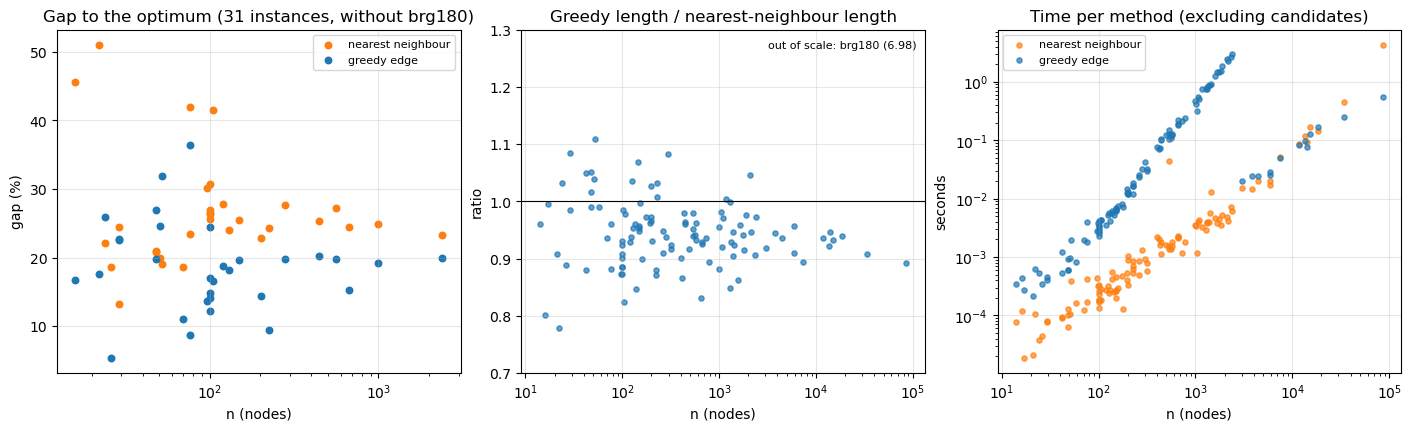

In [14]:
colors = {"nn": "tab:orange", "greedy": "tab:blue"}
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), layout="constrained")

ax = axes[0]
sel = with_opt.drop("brg180")
for m in METHODS:
    ax.scatter(sel["n"], sel[f"{m}_gap"], s=22, color=colors[m], label=NAMES[m])
ax.set(xscale="log", title=f"Gap to the optimum ({len(sel)} instances, without brg180)",
       xlabel="n (nodes)", ylabel="gap (%)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
ax.scatter(results["n"], results["ratio"], s=14, color="tab:blue", alpha=0.7)
ax.axhline(1, color="black", lw=0.8)
ax.set(xscale="log", ylim=(0.7, 1.3), title="Greedy length / nearest-neighbour length",
       xlabel="n (nodes)", ylabel="ratio")
outside = results[results["ratio"] > 1.3]
ax.text(0.98, 0.97, "out of scale: " + ", ".join(f"{i} ({r:.2f})" for i, r in outside["ratio"].items()),
        transform=ax.transAxes, ha="right", va="top", fontsize=8)
ax.grid(alpha=0.3)

ax = axes[2]
for m in METHODS:
    ax.scatter(results["n"], results[f"{m}_time"], s=14, color=colors[m], alpha=0.7, label=NAMES[m])
ax.set(xscale="log", yscale="log", title="Time per method (excluding candidates)",
       xlabel="n (nodes)", ylabel="seconds")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

Path("figures").mkdir(exist_ok=True)
fig.savefig("figures/results.pdf")
fig.savefig("figures/results.png", dpi=200)
plt.show()

Tours of `eil51` (the red dot is node 1, where nearest neighbour starts): nearest neighbour and greedy edge against the optimum. Greedy edge shows its weak point: the long jumps of the final joining of fragments.

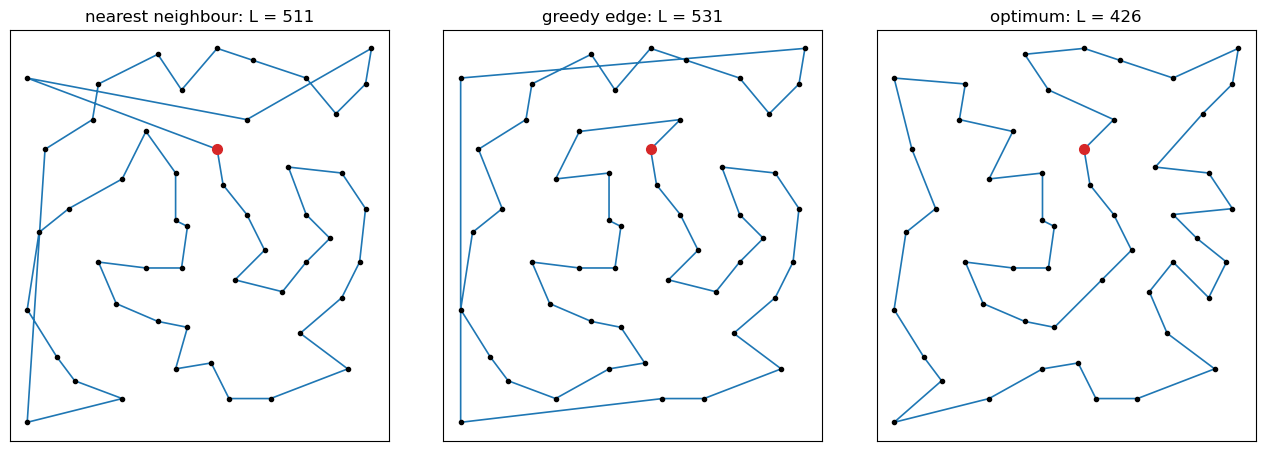

In [15]:
inst = instances["eil51"]
panels = {"nearest neighbour": example_tours["nn"], "greedy edge": example_tours["greedy"],
          "optimum": optimal["eil51"][0]}
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4), layout="constrained")

for ax, (title, tour) in zip(axes, panels.items()):
    xy = inst.coords[np.r_[tour, tour[0]]]
    ax.plot(xy[:, 0], xy[:, 1], "-", lw=1.2, color="tab:blue")
    ax.plot(inst.coords[:, 0], inst.coords[:, 1], "o", ms=3, color="black")
    ax.plot(*inst.coords[0], "o", ms=7, color="tab:red")
    ax.set(title=f"{title}: L = {inst.tour_length(tour):.0f}", xticks=[], yticks=[])
    ax.set_aspect("equal")

fig.savefig("figures/eil51_tours.pdf")
fig.savefig("figures/eil51_tours.png", dpi=200)
plt.show()

### Notes

**`brg180` is a pathological instance.** It has only six distinct weights (0, 20, 30, 3500, 9000 and 10000) and thousands of ties at weight 30. Greedy first consumes the cheapest edges (the 90 of weight 0 and 75 of weight 20) and corners itself: it ends up paying for 4 edges of weight 9000, whereas the optimum uses 15 of weight 30. The result is 37,830 against 1950. This is a property of the instance and not a bug in the code, which is why the averages are given with and without it.

**Candidates versus exact greedy.** With only 10 neighbours the tour changed in 42 of the 81 small instances without fixed edges that were compared while developing the code, with differences of up to ±10 % in individual cases and a mean of $-0.1\,\%$. In other words, it does not lose quality systematically, but the result is noisier, especially on instances with dense regions. That is why greedy is exact up to `EXACT_MAX = 2500` nodes and uses candidates above that. The effect on large instances with very dense regions has not been measured.

**No local improvement.** The gaps of greedy edge (around 18–19 % on average on the instances with a known optimum) are typical of a purely constructive heuristic. Its weak points are the final joining of fragments and instances with many ties. A local-improvement phase (2-opt / Or-opt with neighbour lists) or joining the fragments with Savings would be the natural next steps to reduce them.

**Scope of the comparison.** Only 32 of the 111 instances come with an optimal tour. For the rest the methods can only be compared with each other. With the best-known values from TSPLIB the gap could be computed on all of them.